In [1]:
import torch
from torch.nn.functional import pad
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

In [2]:
from tqdm.notebook import tqdm

In [3]:
# need to add path using os and sys first
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
# and now we can import the model
from models.model import MainModelFauxPytorch as MainModel

In [4]:
from datasets import load_from_disk

In [5]:
import tokenmonster

In [6]:
tokenizer_file = "english-8000-balanced-v1"

In [7]:
vocab = tokenmonster.load_multiprocess_safe(tokenizer_file)

In [8]:
initial_vocab_size = len(vocab)

In [9]:
pad_idx = initial_vocab_size
mask_idx = initial_vocab_size + 1

In [10]:
vocab_size = initial_vocab_size + 2

In [11]:
question_len = 256
context_len = 512
answer_len = 9

In [12]:
embedding_dim = 256
num_heads = 8
target_len = answer_len
num_layers = 1
phm_factor = 3
lm_head_phm_factor = 3
batch_size = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [13]:
checkpoint_dir = "checkpoints"
path = f"{checkpoint_dir}/crfmlm_modelpytorchref.pt"

In [14]:
squad_train_file = "data/squad_train"
squad = load_from_disk(squad_train_file)

In [15]:
masking_prob = 0.3
mask_token_prob = 0.8
random_token_prob = 0.1
leave_token_prob = 0.1

In [16]:
from typing import List

# https://github.com/labmlai/annotated_deep_learning_paper_implementations/blob/master/labml_nn/transformers/mlm/__init__.py
# checking to see if it is an issue with my collator


class MLM:
    """
    ## Masked LM (MLM)

    This class implements the masking procedure for a given batch of token sequences.
    """

    def __init__(self, *,
                 padding_token: int, mask_token: int, no_mask_tokens: List[int], n_tokens: int,
                 masking_prob: float = 0.15, randomize_prob: float = 0.1, no_change_prob: float = 0.1,
                 ):
        """
        * `padding_token` is the padding token `[PAD]`.
          We will use this to mark the labels that shouldn't be used for loss calculation.
        * `mask_token` is the masking token `[MASK]`.
        * `no_mask_tokens` is a list of tokens that should not be masked.
        This is useful if we are training the MLM with another task like classification at the same time,
        and we have tokens such as `[CLS]` that shouldn't be masked.
        * `n_tokens` total number of tokens (used for generating random tokens)
        * `masking_prob` is the masking probability
        * `randomize_prob` is the probability of replacing with a random token
        * `no_change_prob` is the probability of replacing with original token
        """
        self.n_tokens = n_tokens
        self.no_change_prob = no_change_prob
        self.randomize_prob = randomize_prob
        self.masking_prob = masking_prob
        self.no_mask_tokens = no_mask_tokens + [padding_token, mask_token]
        self.padding_token = padding_token
        self.mask_token = mask_token

    def __call__(self, x: torch.Tensor):
        """
        * `x` is the batch of input token sequences.
         It's a tensor of type `long` with shape `[seq_len, batch_size]`.
        """

        # Mask `masking_prob` of tokens
        full_mask = torch.rand(x.shape, device=x.device) < self.masking_prob
        # Unmask `no_mask_tokens`
        for t in self.no_mask_tokens:
            full_mask &= x != t

        # A mask for tokens to be replaced with original tokens
        unchanged = full_mask & (torch.rand(x.shape, device=x.device) < self.no_change_prob)
        # A mask for tokens to be replaced with a random token
        random_token_mask = full_mask & (torch.rand(x.shape, device=x.device) < self.randomize_prob)
        # Indexes of tokens to be replaced with random tokens
        random_token_idx = torch.nonzero(random_token_mask, as_tuple=True)
        # Random tokens for each of the locations
        random_tokens = torch.randint(0, self.n_tokens, (len(random_token_idx[0]),), device=x.device)
        # The final set of tokens that are going to be replaced by `[MASK]`
        mask = full_mask & ~random_token_mask & ~unchanged

        # Make a clone of the input for the labels
        y = x.clone()

        # Replace with `[MASK]` tokens;
        # note that this doesn't include the tokens that will have the original token unchanged and
        # those that get replace with a random token.
        x.masked_fill_(mask, self.mask_token)
        # Assign random tokens
        x[random_token_idx] = random_tokens

        # Assign token `[PAD]` to all the other locations in the labels.
        # The labels equal to `[PAD]` will not be used in the loss.
        y.masked_fill_(~full_mask, self.padding_token)

        # Return the masked input and the labels
        return x, y

In [17]:
mlm = MLM(padding_token=pad_idx, mask_token=mask_idx, no_mask_tokens=[mask_idx, pad_idx], n_tokens=vocab_size, masking_prob=masking_prob, randomize_prob=random_token_prob, no_change_prob=leave_token_prob)

In [18]:
def collate_fn(batch, question_key, context_key, answer_key):
    """
    Each batch has 3 elements: instruction, context, response
    However since their lengths may vary, we need to pad them.

    For response, must ensure that we add eos token and then begin padding.
    """
    answers = []

    for elem in batch:
        i = elem[question_key]
        c = elem[context_key]
        r = elem[answer_key]

        # combine them all into one sequence
        # combined = torch.cat((i, c, r))
        # answers.append(combined)

        # ensure r is at most answer_len
        r = r[:answer_len]
        answers.append(r) # for now, just use the response to speedup debugging

    # the answers are the targets for masked language modeling
    # Pad answers to answer_len + question_len + context_len
    # answers = [pad(r, (0, (answer_len + question_len + context_len) - len(r)), value=pad_idx) for r in answers]
    answers = [pad(r, (0, answer_len - len(r)), value=pad_idx) for r in answers]

    answers = torch.stack(answers)

    # answer_masking = torch.rand(answers.shape) < masking_prob
    # answer_masking[answers >= pad_idx] = False # don't mask padding tokens nor mask tokens
    # targets = torch.ones(answers.shape) * pad_idx
    # # ensure targets and answers are of the same dtype
    # targets = targets.type_as(answers)
    # targets[answer_masking] = answers[answer_masking]

    # # 80% of the time, replace masked input tokens with tokenizer.mask_token ([MASK])
    # # 10% of the time, replace with random token
    # # 10% of the time, keep original
    # masked_answers = answers.clone()
    # masking_mask = answer_masking & (torch.rand(answers.shape) < mask_token_prob)
    # random_mask = answer_masking & ~masking_mask & (torch.rand(answers.shape) < random_token_prob)
    # masked_answers[masking_mask] = mask_idx
    # masked_answers[random_mask] = torch.randint(0, vocab_size, (random_mask.sum().item(),))
    masked_answers, targets = mlm(answers)

    return masked_answers, targets, answers

In [19]:
def squad_collate_fn(batch):
    return collate_fn(batch, "question", "context", "answers")

In [20]:
squadDataloader = DataLoader(squad, batch_size=batch_size, shuffle=True, collate_fn=squad_collate_fn)

In [21]:
from torch.optim import Adam
import datetime

In [22]:
def save_checkpoint(losses, model, optm, tensorboard_log_dir):
    # first check to see if checkpoint dir exists, if not, create it
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    torch.save({
    'epoch': len(losses),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optm.state_dict(),
    'loss': losses[-1],
    'losses': losses,
    'model_kwargs': model.kwargs,
    'tensorboard_log_dir': tensorboard_log_dir
    }, path)
def load_checkpoint(map_location=None):
    checkpoint = torch.load(path, map_location=map_location)
    model = MainModel(**checkpoint['model_kwargs'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    optm = torch.optim.Adam(model.parameters(), lr=0.001)
    optm.load_state_dict(checkpoint['optimizer_state_dict'])
    losses = checkpoint['losses']
    log_dir = checkpoint['tensorboard_log_dir']
    return losses, model, optm, log_dir
def try_loading():
    """
    First try to load the model, if it doesn't exist, create one
    based on the parameters specified above
    """
    try:
        losses, model, optm, log_dir = load_checkpoint()
        print(f"Resuming, have seen {len(losses)} epochs")
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir
    except FileNotFoundError:
        # couldn't find model, probably because it doesn't exist
        print("Couldn't find model, creating new one")
        model = MainModel(vocab_size, embedding_dim, num_heads, phm_factor, vocab_phm_factor=lm_head_phm_factor, num_layers=num_layers)
        model = model.to(device)
        optm = Adam(model.parameters(), lr=0.001)
        losses = []
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        # create a string to identify this model for tensorboard logging
        now = datetime.datetime.now()
        log_dir = f"runs/run_at_{now.strftime('%Y-%m-%d_%H-%M-%S')}"
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir
    except RuntimeError:
        # probably because model was saved on gpu and now we're using cpu
        # so can still load it, but need to specify map_location
        print("Model found but was saved on gpu, attempting to load on cpu")
        losses, model, optm, log_dir = load_checkpoint(map_location='cpu')
        print(f"Resuming, have seen {len(losses)} epochs")
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir

In [23]:
losses, model, optm, log_dir = try_loading()

Couldn't find model, creating new one
Have 5420610 trainable parameters
Logging to runs/run_at_2023-11-23_20-12-44


In [24]:
writer = SummaryWriter(log_dir=log_dir)

In [25]:
squad_iter = iter(squadDataloader)

In [26]:
total_epochs = 5000
seen = len(losses)
remaining_epochs = total_epochs - seen
print(f"Seen {seen} epochs, {remaining_epochs} remaining for a total of {total_epochs}")

Seen 0 epochs, 5000 remaining for a total of 5000


In [27]:
# tets suggest we can overfit on a single batch, so probably not something wrong with model

In [28]:
for epoch in (pbar := tqdm(range(remaining_epochs))):
    try:
        batch = next(squad_iter)
    except StopIteration:
        squad_iter = iter(squadDataloader)
        batch = next(squad_iter)
    masked_answers, targets, _ = batch
    masked_answers = masked_answers.to(device)
    targets = targets.to(device)

    logits = model(masked_answers)
    loss = torch.nn.functional.cross_entropy(logits.view(-1, vocab_size), targets.view(-1), ignore_index=pad_idx)
    optm.zero_grad()
    loss.backward()
    optm.step()

    pbar.set_description(f"Epoch {epoch + seen} | Loss: {loss.item():.4f}")
    writer.add_scalar("loss", loss.item(), epoch + seen)
    losses.append(loss.item())
    if epoch % 10 == 0:
        save_checkpoint(losses, model, optm, log_dir)

  0%|          | 0/5000 [00:00<?, ?it/s]

In [ ]:
save_checkpoint(losses, model, optm, log_dir)
writer.close()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

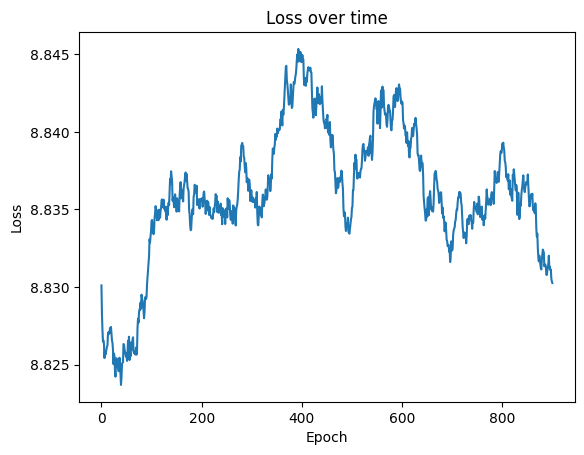

In [ ]:
# plot the losses with smoothing
window_size = 100
avg = np.convolve(losses, np.ones(window_size), mode='valid') / window_size
plt.plot(avg)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Loss over time')
plt.show()